### Capstone Project PoC using 2-4weeks fo data
Muzaffar Izamuddin bin Daud
P166246

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muzaffarizamuddin/Muzaffar_Capstone/blob/main/main.ipynb)

In [15]:
import glob
import os
import pandas as pd

# Download data from google drive, this uses OAuth, so only approved person can view the data
FOLDER_ID = "1K9P0b_zeGjsLX39WGfnsWQNOGPbFeYlS"
DATA_DIR = "data"

def download_drive_folder(folder_id, target_dir):
    """Authenticates the user and downloads all CSV files from a specific Google Drive folder."""
    print(
        f"'{target_dir}' folder not found. Authenticating to download from Google Drive..."
    )

    try:
        # 1. First choice: Use Google Colab's native authentication wrapper if running in the cloud
        from google.colab import auth
        from googleapiclient.discovery import build

        auth.authenticate_user()
        drive_service = build("drive", "v3")
    except ImportError:
        # 2. Local Fallback: Standard Jupyter Notebooks / VS Code
        from google.auth.transport.requests import Request
        from google.oauth2.credentials import Credentials
        from google_auth_oauthlib.flow import InstalledAppFlow
        from googleapiclient.discovery import build

        SCOPES = ["https://www.googleapis.com/auth/drive.readonly"]
        creds = None

        # Check if a prior session token exists to bypass browser logins
        if os.path.exists("token.json"):
            creds = Credentials.from_authorized_user_file("token.json", SCOPES)

        # If no valid token exists, initiate user authentication via browser
        if not creds or not creds.valid:
            if creds and creds.expired and creds.refresh_token:
                creds.refresh(Request())
            else:
                if not os.path.exists("credentials.json"):
                    raise FileNotFoundError(
                        "Missing 'credentials.json' file! Please place it in your working directory."
                    )
                flow = InstalledAppFlow.from_client_secrets_file(
                    "credentials.json", SCOPES
                )
                creds = flow.run_local_server(port=0)

            # Save the session token for subsequent runs
            with open("token.json", "w") as token:
                token.write(creds.to_json())

        drive_service = build("drive", "v3", credentials=creds)

    # Ensure local data directory exists
    os.makedirs(target_dir, exist_ok=True)

    # Query to list all CSV files inside the specific parent folder
    query = f"'{folder_id}' in parents and mimeType = 'text/csv' and trashed = false"
    results = (
        drive_service.files()
        .list(q=query, fields="files(id, name)")
        .execute()
    )
    items = results.get("files", [])

    if not items:
        print("No CSV files found in the specified Drive folder.")
        return

    print(f"Found {len(items)} files. Downloading...")
    for item in items:
        file_id = item["id"]
        file_name = item["name"]
        file_path = os.path.join(target_dir, file_name)

        print(f"Downloading {file_name}...")
        request = drive_service.files().get_media(fileId=file_id)

        with open(file_path, "wb") as f:
            f.write(request.execute())
    print("Download complete!\n")


# 1. Check and Auto-Download Data
if not os.path.exists(DATA_DIR) or not os.listdir(DATA_DIR):
    download_drive_folder(FOLDER_ID, DATA_DIR)

# 2. Load All Data
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
list_df = []

for filename in all_files:
    df = pd.read_csv(filename)
    list_df.append(df)

if list_df:
    data2 = pd.concat(list_df, ignore_index=True)

    # 3. Clean 'Date' and create 'source' from Timezone
    data2["Date"] = pd.to_datetime(data2["Date"], format="ISO8601")
    data2["source"] = data2["@mqtt_attribute.timezone"].str.split("/").str[-1]

    # 4. Sort chronologically by device and time
    data2 = data2.sort_values(by=["device.id", "Date"]).reset_index(drop=True)

    print(f"Total rows: {len(data2)}")
    print(f"Cities detected: {data2['source'].unique()}")
else:
    print("No data available to process.")

C:\Users\user\AppData\Local\Temp\ipykernel_18004\4254708771.py:95: DtypeWarning: Columns (0: mqtt_state.temp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


Total rows: 827845
Cities detected: ['Canberra' 'Darwin' 'Perth' 'Melbourne' 'Hobart' 'Broken_Hill' 'Adelaide'
 'Brisbane' 'Sydney']


In [16]:
import glob
import os
import pandas as pd

FOLDER_ID = "1K9P0b_zeGjsLX39WGfnsWQNOGPbFeYlS"
DATA_DIR = "data"

# ==========================================
# 1. Check and Auto-Download Data (ONLY downloads if missing)
# ==========================================
if not os.path.exists(DATA_DIR) or not os.listdir(DATA_DIR):
    download_drive_folder(FOLDER_ID, DATA_DIR)

# ==========================================
# 2. Load All Data (Runs EVERY time)
# ==========================================
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
list_df = []

for filename in all_files:
    df = pd.read_csv(filename)
    list_df.append(df)

if not list_df:
    raise FileNotFoundError(
        f"No CSV files found in '{DATA_DIR}'. Please check the folder."
    )

data2 = pd.concat(list_df, ignore_index=True)

# ==========================================
# 3. Clean & Sort (Runs EVERY time - guarantees 'source' exists)
# ==========================================
# Convert Date to datetime objects
data2["Date"] = pd.to_datetime(data2["Date"], format="ISO8601")

# Extract city name to create 'source'
data2["source"] = data2["@mqtt_attribute.timezone"].str.split("/").str[-1]

# Sort chronologically by device and time
data2 = data2.sort_values(by=["device.id", "Date"]).reset_index(drop=True)

print(f"Total rows successfully loaded: {len(data2)}")
print(f"Cities detected: {data2['source'].unique()}")

C:\Users\user\AppData\Local\Temp\ipykernel_18004\1200464405.py:21: DtypeWarning: Columns (0: mqtt_state.temp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


Total rows successfully loaded: 827845
Cities detected: ['Canberra' 'Darwin' 'Perth' 'Melbourne' 'Hobart' 'Broken_Hill' 'Adelaide'
 'Brisbane' 'Sydney']


In [5]:
data2.head()

,Date,Host,Service,device.id,mqtt_data.hum,mqtt_data.temp,mqtt_state.pwr,mqtt_state.temp,mqtt_state.mode,mqtt_state.fan,@mqtt_state.hlouve,@mqtt_state.vlouve,@mqtt_attribute.timezone,Content,source
0,2026-04-15 09:24:40.866000+00:00,arn:aws:lambda:ap-southeast-2:894831754756:fun...,airtouch-beam-rules-device-message,A09001396,54.5,20.3,off,21.0,cool,auto,on,off,Australia/Canberra,2026-04-15T09:24:40.866Z\t18823bcb-eff8-4a71-a...,Canberra
1,2026-04-15 09:39:41.019000+00:00,arn:aws:lambda:ap-southeast-2:894831754756:fun...,airtouch-beam-rules-device-message,A09001396,54.8,20.2,off,21.0,cool,auto,on,off,Australia/Canberra,2026-04-15T09:39:41.019Z\tc973c206-54b7-4261-a...,Canberra
2,2026-04-15 09:54:41.520000+00:00,arn:aws:lambda:ap-southeast-2:894831754756:fun...,airtouch-beam-rules-device-message,A09001396,55.0,20.0,off,21.0,cool,auto,on,off,Australia/Canberra,2026-04-15T09:54:41.520Z\te6f89f12-f67b-45ee-a...,Canberra
3,2026-04-15 10:09:03.897000+00:00,arn:aws:lambda:ap-southeast-2:894831754756:fun...,airtouch-beam-rules-device-message,A09001396,55.1,20.0,off,21.0,cool,auto,on,off,Australia/Canberra,2026-04-15T10:09:03.897Z\t2b4c6509-5f96-4753-b...,Canberra
4,2026-04-15 10:09:41.657000+00:00,arn:aws:lambda:ap-southeast-2:894831754756:fun...,airtouch-beam-rules-device-message,A09001396,55.2,20.0,off,21.0,cool,auto,on,off,Australia/Canberra,2026-04-15T10:09:41.657Z\tdd0170b9-723f-4432-b...,Canberra


In [17]:
# Aggregate unique device counts, earliest date, and latest date per city
city_summary = data2.groupby('source').agg(
    Unique_Devices=('device.id', 'nunique'),
    Earliest_Date=('Date', 'min'),
    Latest_Date=('Date', 'max')
).reset_index()

# Rename columns for a clean presentation
city_summary.columns = ['City', 'Unique Device Count', 'Earliest Date', 'Latest Date']

# Display the summary sorted by the highest device count
print(city_summary.sort_values(by='Unique Device Count', ascending=False).to_string(index=False))

       City  Unique Device Count                    Earliest Date                      Latest Date
      Perth                   58 2026-04-15 09:01:37.348000+00:00 2026-05-17 02:06:04.552000+00:00
  Melbourne                   55 2026-04-15 09:32:24.683000+00:00 2026-05-17 02:29:43.139000+00:00
     Sydney                   54 2026-04-15 09:21:52.699000+00:00 2026-05-17 02:36:31.203000+00:00
   Adelaide                   51 2026-04-15 09:34:59.058000+00:00 2026-05-17 02:12:49.218000+00:00
   Brisbane                   46 2026-04-15 09:25:53.978000+00:00 2026-05-17 02:20:01.175000+00:00
     Darwin                    3 2026-04-15 09:43:30.215000+00:00 2026-05-17 02:42:37.572000+00:00
     Hobart                    2 2026-04-15 09:34:50.132000+00:00 2026-05-17 02:42:50.846000+00:00
   Canberra                    1 2026-04-15 09:24:40.866000+00:00 2026-05-17 02:42:06.325000+00:00
Broken_Hill                    1 2026-04-15 09:45:13.572000+00:00 2026-05-17 02:21:30.776000+00:00


🔍 Searching for shapefile folder locally at: d:\github\Capstone\Muzaffar_Capstone\shapefile
🌍 Geocoding city names to coordinates...
🗺️ Rendering Map visualization...


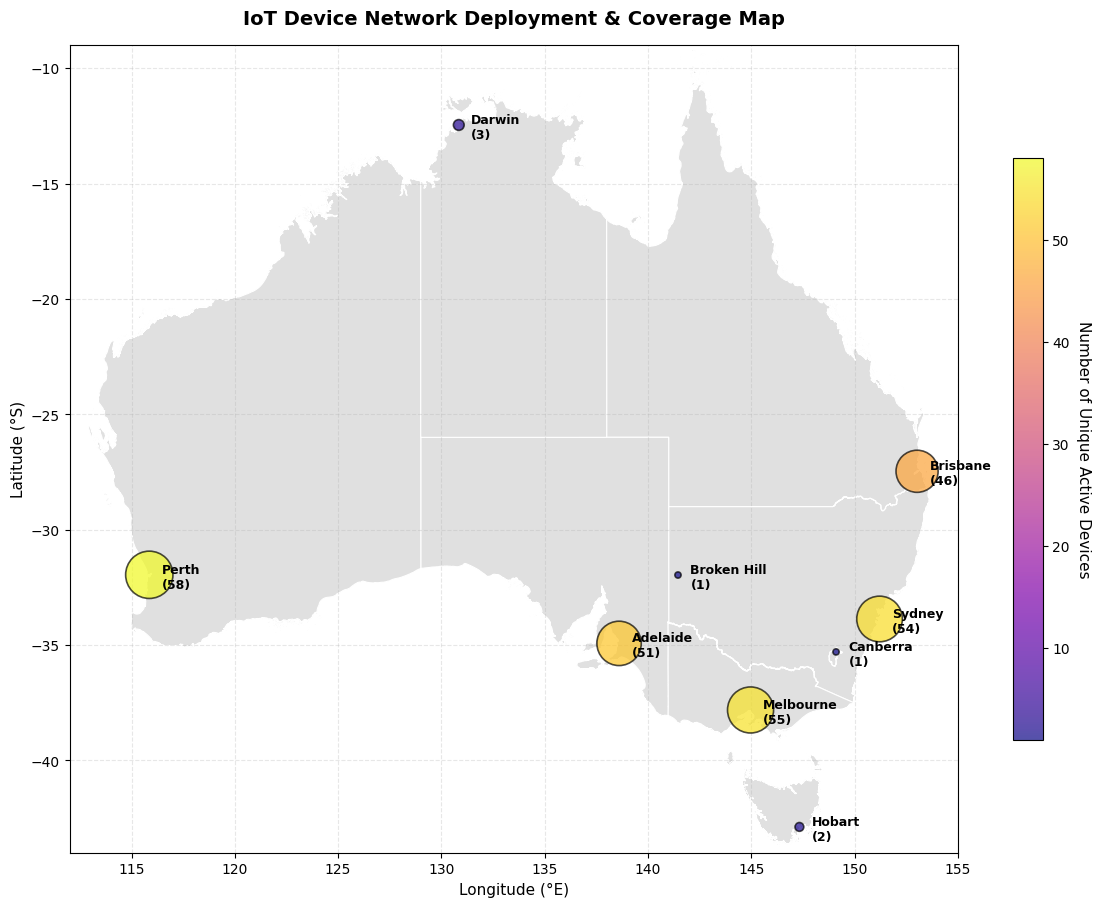

In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import numpy as np
import os
import requests

# =====================================================================
# 1. Configuration & Auto-Download Setup
# =====================================================================
# Dynamic directory detection (Works for standard scripts and Jupyter Notebooks)
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    try:
        SCRIPT_DIR = get_ipython().user_ns.get('_dh')[0]
    except (NameError, TypeError):
        SCRIPT_DIR = os.getcwd()

SHAPEFILE_DIR = os.path.join(SCRIPT_DIR, "shapefile")
SHAPEFILE_NAME = "STE_2021_AUST_GDA2020.shp" 
SHAPEFILE_PATH = os.path.join(SHAPEFILE_DIR, SHAPEFILE_NAME)

# Target GitHub API details (Public fallback repo now made primary)
REPO_API_URL = "https://api.github.com/repos/muzaffarizamuddin/unstructured_course/contents/shapefile"

def download_shapefile_from_github(target_dir):
    """Fetches directory contents via GitHub API and downloads all files inside."""
    print("⏳ Shapefile not found locally. Attempting to download from GitHub...")
    os.makedirs(target_dir, exist_ok=True)
    
    try:
        print(f"📡 Querying GitHub repository contents at: {REPO_API_URL}")
        response = requests.get(REPO_API_URL)
        if response.status_code == 200:
            files = response.json()
            for file_info in files:
                # We only need individual files
                if file_info['type'] == 'file':
                    file_name = file_info['name']
                    download_url = file_info['download_url']
                    local_file_path = os.path.join(target_dir, file_name)
                    
                    print(f"   📥 Downloading {file_name}...")
                    file_res = requests.get(download_url)
                    if file_res.status_code == 200:
                        with open(local_file_path, 'wb') as f:
                            f.write(file_res.content)
                    else:
                        print(f"   ❌ Failed to download {file_name}")
            print("✅ All shapefile components downloaded successfully!")
        else:
            print(f"❌ Failed to reach GitHub API. Status code: {response.status_code}")
            print("Please ensure the repository is public and the URL is correct.")
    except Exception as e:
        print(f"❌ An error occurred during download: {e}")

# Check local existence of the primary .shp file; download if missing
print(f"🔍 Searching for shapefile folder locally at: {SHAPEFILE_DIR}")
if not os.path.exists(SHAPEFILE_PATH):
    download_shapefile_from_github(SHAPEFILE_DIR)
    
    # Re-verify after download attempt
    if not os.path.exists(SHAPEFILE_PATH):
        # Fallback check: look for any .shp file in the folder if exact name didn't match
        if os.path.exists(SHAPEFILE_DIR):
            shp_files = [f for f in os.listdir(SHAPEFILE_DIR) if f.endswith('.shp')]
            if shp_files:
                SHAPEFILE_PATH = os.path.join(SHAPEFILE_DIR, shp_files[0])
                print(f"ℹ️ Found shapefile dynamically at: {SHAPEFILE_PATH}")
            else:
                raise FileNotFoundError(f"Could not find or download the core .shp file into '{SHAPEFILE_DIR}'.")
        else:
            raise FileNotFoundError(f"Could not find or download shapefile components.")

# Load the Australian map outline
australia_map = gpd.read_file(SHAPEFILE_PATH)

# =====================================================================
# 2. Dynamic Geocoding Layer (Handles any number of cities)
# =====================================================================
print("🌍 Geocoding city names to coordinates...")

# Prepare city name strings (Replacing underscores with spaces for the search engine)
city_summary['Clean_City'] = city_summary['City'].str.replace('_', ' ') + ", Australia"

# Initialize Geolocator (Uses OpenStreetMap data)
geolocator = Nominatim(user_agent="iot_device_tracker_aus")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Dynamically lookup Latitude & Longitude for every unique city present
latitudes, longitudes = [], []
for city in city_summary['Clean_City']:
    try:
        location = geocode(city)
        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
        else:
            latitudes.append(np.nan)
            longitudes.append(np.nan)
    except Exception:
        latitudes.append(np.nan)
        longitudes.append(np.nan)

city_summary['Latitude'] = latitudes
city_summary['Longitude'] = longitudes

# Convert the summary summary into a true GeoDataFrame
gdf_devices = gpd.GeoDataFrame(
    city_summary, 
    geometry=gpd.points_from_xy(city_summary.Longitude, city_summary.Latitude),
    crs="EPSG:4326"
)

# Ensure the shapefile map and our points share the same Coordinate Reference System (CRS)
if australia_map.crs != "EPSG:4326":
    australia_map = australia_map.to_crs("EPSG:4326")

# Filter out rows that failed to geocode safely
gdf_devices = gdf_devices.dropna(subset=['Latitude', 'Longitude'])

# =====================================================================
# 3. Plotting using GeoPandas Map Background
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the background shapefile layers (gray landmass with white borders)
australia_map.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.8)

# Calculate bubble scaling (Adjust this scalar if bubbles need to be resized)
bubble_scale = 20
sizes = gdf_devices['Unique Device Count'] * bubble_scale

# Superimpose the device coverage bubbles onto the shapefile map
scatter = ax.scatter(
    gdf_devices.geometry.x, 
    gdf_devices.geometry.y, 
    s=sizes, 
    c=gdf_devices['Unique Device Count'], 
    cmap='plasma', 
    alpha=0.7, 
    edgecolors="black", 
    linewidth=1.2,
    zorder=3  # Pushes points above background shape layers
)

# 4. Annotate City Labels cleanly
for idx, row in gdf_devices.iterrows():
    ax.text(
        row.geometry.x + 0.6, 
        row.geometry.y - 0.1, 
        f"{row['City'].replace('_', ' ')}\n({int(row['Unique Device Count'])})", 
        fontsize=9, 
        weight='bold',
        va='center',
        zorder=4
    )

# 5. Styling & Visual Framing
ax.set_title('IoT Device Network Deployment & Coverage Map', fontsize=14, weight='bold', pad=15)
ax.set_xlabel('Longitude (°E)', fontsize=11)
ax.set_ylabel('Latitude (°S)', fontsize=11)

# Add colorbar scale matrix
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label('Number of Unique Active Devices', fontsize=11, rotation=270, labelpad=15)

# Crop coordinates window to frame Australia tightly (removes outer ocean data blocks)
ax.set_xlim(112, 155)
ax.set_ylim(-44, -9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
print("🗺️ Rendering Map visualization...")
plt.show()

In [24]:
# this cell is a function for plotting
import matplotlib.pyplot as plt
import numpy as np

def plot_device_decomposition_grid(df, model_dict, device_ids='All', cities='All', targets='All'):
    # 1. Safe Filtering Logic
    plot_df = df.copy()
    
    # Safely extract text names for filtering
    if 'source' in plot_df.columns:
        # Check if the column is currently numeric/encoded
        if np.issubdtype(plot_df['source'].dtype, np.integer) or plot_df['source'].dtype.name == 'int64':
            plot_df['source_name'] = encoders['source'].inverse_transform(plot_df['source'].astype(int))
        else:
            plot_df['source_name'] = plot_df['source'].astype(str)
            # Temporarily force 'source' to be numeric so models don't crash
            plot_df['source'] = encoders['source'].transform(plot_df['source_name'])

    # Apply City Filter
    if cities != 'All':
        cities = [cities] if isinstance(cities, str) else cities
        plot_df = plot_df[plot_df['source_name'].isin(cities)]
    
    # Apply Device Filter
    if device_ids != 'All':
        device_ids = [device_ids] if isinstance(device_ids, str) else device_ids
        plot_df = plot_df[plot_df['device.id'].isin(device_ids)]
        
    targets = target_cols if targets == 'All' else ([targets] if isinstance(targets, str) else targets)
    unique_devices = plot_df['device.id'].unique()
    
    if len(unique_devices) == 0:
        print(f"No devices found for filter: cities={cities}, device_ids={device_ids}")
        return
    
    # 2. Grid Setup (4 Columns Wide)
    max_cols = 4  
    num_rows_per_device = 1 + len(targets)
    ratios = [2] + ([1] * len(targets))
    
    for i in range(0, len(unique_devices), max_cols):
        current_devices = unique_devices[i : i + max_cols]
        num_cols = len(current_devices)
        
        total_height = 3 + (len(targets) * 1.5)
        
        fig = plt.figure(figsize=(num_cols * 5, total_height), constrained_layout=True)
        subfigs = fig.subfigures(1, num_cols, wspace=0.1)
        if num_cols == 1: subfigs = [subfigs]

        for col_idx, dev_id in enumerate(current_devices):
            dev_data = plot_df[plot_df['device.id'] == dev_id].sort_values('Date').reset_index(drop=True)
            
            # Establish the split point natively relative to the passed DataFrame length
            split_point = int(len(dev_data) * 0.5)
            
            axes = subfigs[col_idx].subplots(num_rows_per_device, 1, sharex=True, 
                                            gridspec_kw={'hspace': 0.05, 'height_ratios': ratios})
            
            subfigs[col_idx].suptitle(f"{dev_id} ({dev_data['source_name'].iloc[0]})", 
                                      fontweight='bold', fontsize=11)

            # --- Row 0: Environmental ---
            ax0 = axes[0]
            ax0_twin = ax0.twinx()
            ax0.plot(dev_data['Date'], dev_data['mqtt_data.temp'], color='red', alpha=0.5, label='T')
            ax0_twin.plot(dev_data['Date'], dev_data['mqtt_data.hum'], color='blue', alpha=0.5, label='H')
            ax0.set_ylabel("Env", fontsize=8)
            ax0.tick_params(labelsize=7)

            # --- Rows 1 to N: Targets ---
            for t_idx, target in enumerate(targets):
                ax = axes[t_idx + 1]
                
                model_entry = model_dict[target]
                X_dev = dev_data[feature_cols].astype(float)
                
                # Dynamic prediction execution based on model type
                if isinstance(model_entry, tuple):  # XGBoost Model Tuple
                    model, le_target = model_entry
                    preds_raw = model.predict(X_dev)
                    preds = le_target.inverse_transform(preds_raw) if le_target else preds_raw
                else:  # Logistic Regression Pipeline
                    preds = model_entry.predict(X_dev)

                # Plot Actual metrics over the full duration
                ax.plot(dev_data['Date'], dev_data[target], color='black', alpha=0.3, linewidth=1)
                
                # Plot Predicted tracking only for the testing sequence window
                ax.plot(dev_data['Date'].iloc[split_point:], preds[split_point:], 
                        color='red', linestyle='--', linewidth=1.2)
                
                short_label = target.split('.')[-1]
                ax.set_ylabel(short_label, fontsize=8)
                ax.tick_params(axis='y', labelsize=7)
                
                if t_idx == len(targets) - 1:
                    ax.tick_params(axis='x', rotation=45, labelsize=7)

        plt.show()

In [25]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error

# ==========================================
# 1. Reset & Create a Fresh Copy of Data
# ==========================================
df_processed = data2.copy()

# Re-extract fresh text strings for 'source' to clear any previous integer codes
df_processed["source"] = df_processed["@mqtt_attribute.timezone"].str.split("/").str[-1]

# 🔍 FIX: Purify core numeric columns before lagging so they don't break types or trigger LabelEncoder
numeric_base_cols = ['mqtt_data.hum', 'mqtt_data.temp', 'mqtt_state.temp']
for col in numeric_base_cols:
    if col in df_processed.columns:
        # Cast to string, strip literal single/double quotes and surrounding whitespace
        df_processed[col] = df_processed[col].astype(str).str.replace("'", "", regex=False).str.replace('"', '', regex=False).str.strip()
        # Convert safely to numeric float; any unparseable anomalies become NaN
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

# ==========================================
# 2. Define Targets & Lag Features
# ==========================================
target_cols = [
    'mqtt_state.pwr', 
    'mqtt_state.temp', 
    'mqtt_state.mode', 
    'mqtt_state.fan', 
    '@mqtt_state.hlouve', 
    '@mqtt_state.vlouve'
]

# Create lag features within groups (lag_mqtt_state.temp will now be a clean numeric float)
for col in target_cols:
    df_processed[f'lag_{col}'] = df_processed.groupby(['device.id', 'source'])[col].shift(1)

# Drop rows containing NaNs introduced by the shift or unparseable text
df_processed.dropna(inplace=True)

# Define features
feature_cols = ['mqtt_data.hum', 'mqtt_data.temp'] + [f'lag_{c}' for c in target_cols]

# ==========================================
# 3. Safe Encoding (Resets every time)
# ==========================================
encoders = {}

# 1. Guarantee 'source' encoder is explicitly fit and stored as clean strings
le_source = LabelEncoder()
df_processed['source'] = le_source.fit_transform(df_processed['source'].astype(str))
encoders['source'] = le_source

# 2. Encode remaining features ONLY if they are genuinely text/categorical strings
for col in feature_cols:
    if df_processed[col].dtype == "object" or df_processed[col].dtype.name == "str":
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        encoders[col] = le

# ==========================================
# 4. PER-DEVICE 50/50 Split
# ==========================================
train_list, test_list = [], []
for _, group in df_processed.groupby(['device.id', 'source']):
    split_idx = int(len(group) * 0.5)
    train_list.append(group.iloc[:split_idx])
    test_list.append(group.iloc[split_idx:])

train_df = pd.concat(train_list).copy()
test_df = pd.concat(test_list).copy()

print("Data processing and encoding complete!")
print(f"Encoder classes successfully recovered: {encoders['source'].classes_}")

Data processing and encoding complete!
Encoder classes successfully recovered: ['Adelaide' 'Brisbane' 'Broken_Hill' 'Canberra' 'Darwin' 'Hobart'
 'Melbourne' 'Perth' 'Sydney']


In [26]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_results = {}
lr_models = {}

for target in target_cols:
    if target == 'mqtt_state.temp':
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', LinearRegression())
        ])
        y_train = train_df[target]
        y_test = test_df[target]
        model.fit(train_df[feature_cols], y_train)
        preds = model.predict(test_df[feature_cols])
        lr_results[target] = f"MAE: {mean_absolute_error(y_test, preds):.4f}"
    else:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(max_iter=1000))
        ])
        y_train = train_df[target].astype(str)
        y_test = test_df[target].astype(str)
        model.fit(train_df[feature_cols], y_train)
        preds = model.predict(test_df[feature_cols])
        lr_results[target] = f"Accuracy: {accuracy_score(y_test, preds):.2%}"
    
    lr_models[target] = model

print("--- Global Logistic Regression Performance ---")
for target, perf in lr_results.items():
    print(f"{target:25} | {perf}")

# --- Output 2: Device-Specific Performance Table ---
device_table_lr = []

for (dev_id, source_code), dev_data in test_df.groupby(['device.id', 'source']):
    city_name = encoders['source'].inverse_transform([int(source_code)])[0]
    row = {'device.id': dev_id, 'source': city_name}
    
    for target in target_cols:
        model = lr_models[target]
        X_dev = dev_data[feature_cols]
        y_dev = dev_data[target]
        preds = model.predict(X_dev)
        
        if target == 'mqtt_state.temp':
            # Store as number
            row[target] = mean_absolute_error(y_dev, preds)
        else:
            # CHANGE HERE: Store as a float (e.g., 0.985) NOT a string
            row[target] = accuracy_score(y_dev.astype(str), preds)
            
    device_table_lr.append(row)

# 2. Create DataFrame and Sort
final_table_lr = pd.DataFrame(device_table_lr)
final_table_lr = final_table_lr.sort_values(by=['source', 'device.id'])

# 3. Define the formatting for display
format_dict = {col: '{:.1%}' for col in target_cols if col != 'mqtt_state.temp'}
format_dict['mqtt_state.temp'] = '{:.4f}'

# 4. Display the table (Stays numeric in background, shows % in UI)
print("\n--- Device ID vs Performance Metrics (Logistic Regression) ---")
final_table_lr.style.format(format_dict).hide(axis='index')

--- Global Logistic Regression Performance ---
mqtt_state.pwr            | Accuracy: 99.63%
mqtt_state.temp           | MAE: 0.0099
mqtt_state.mode           | Accuracy: 99.96%
mqtt_state.fan            | Accuracy: 99.97%
@mqtt_state.hlouve        | Accuracy: 100.00%
@mqtt_state.vlouve        | Accuracy: 100.00%

--- Device ID vs Performance Metrics (Logistic Regression) ---


device.id,source,mqtt_state.pwr,mqtt_state.temp,mqtt_state.mode,mqtt_state.fan,@mqtt_state.hlouve,@mqtt_state.vlouve
A09020083,Adelaide,99.8%,0.0042,100.0%,100.0%,100.0%,100.0%
A09020427,Adelaide,99.8%,0.0077,100.0%,100.0%,100.0%,100.0%
A09020688,Adelaide,99.8%,0.0066,99.9%,99.9%,100.0%,100.0%
A09020863,Adelaide,99.9%,0.0069,99.9%,99.9%,100.0%,100.0%
A09021039,Adelaide,99.9%,0.0075,99.9%,99.9%,100.0%,100.0%
A09021330,Adelaide,99.9%,0.0030,100.0%,100.0%,100.0%,100.0%
A09021628,Adelaide,99.8%,0.0110,99.8%,100.0%,100.0%,100.0%
A09021668,Adelaide,99.9%,0.0067,99.9%,99.9%,100.0%,100.0%
A09021751,Adelaide,99.3%,0.0058,99.9%,99.9%,100.0%,100.0%
A09021771,Adelaide,100.0%,0.0038,100.0%,100.0%,100.0%,100.0%


In [27]:
# struglling devices for logistic regression
# 1. Define sets of columns
accuracy_cols = [col for col in target_cols if col != 'mqtt_state.temp']
mae_col = 'mqtt_state.temp'

# 2. Logic: Find ANY accuracy < 95% OR Temperature error > 0.5
failed_accuracy = (final_table_lr[accuracy_cols] < 0.95).any(axis=1)
failed_temp = final_table_lr[mae_col] > 0.5

# 3. Filter the dataframe
struggling_devices = final_table_lr[failed_accuracy | failed_temp]

print(f"Found {len(struggling_devices)} devices failing performance thresholds")
struggling_devices.sort_values('source').style.format(format_dict).hide(axis='index')

Found 1 devices failing performance thresholds


device.id,source,mqtt_state.pwr,mqtt_state.temp,mqtt_state.mode,mqtt_state.fan,@mqtt_state.hlouve,@mqtt_state.vlouve
A09023165,Perth,66.7%,0.0278,100.0%,100.0%,100.0%,100.0%


Plotting 1 struggling devices for Logistic Regression...


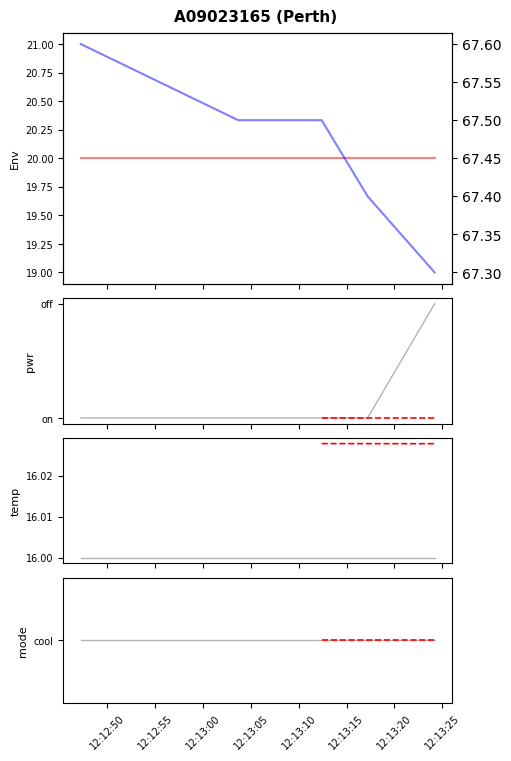

In [28]:
# Extract the unique IDs for Logistic Regression struggling devices
lr_struggling_ids = struggling_devices['device.id'].unique().tolist()

print(f"Plotting {len(lr_struggling_ids)} struggling devices for Logistic Regression...")

# Call the plot function using the Logistic Regression models dictionary
plot_device_decomposition_grid(
    df=df_processed, 
    model_dict=lr_models,           # <--- Uses Logistic Regression models
    cities='All',                   # Checks all cities for these IDs
    device_ids=lr_struggling_ids,   # Only plots these specific devices
    targets=['mqtt_state.pwr', 'mqtt_state.temp', 'mqtt_state.mode']
)

Strugling device is only 1 and it is due to insufficient data

In [29]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_absolute_error

# 6. Training & Global Evaluation
results = {}
models = {} 

for target in target_cols:
    X_train = train_df[feature_cols].astype(float)
    X_test = test_df[feature_cols].astype(float)
    y_train = train_df[target]
    y_test = test_df[target]

    if target == 'mqtt_state.temp':
        model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results[target] = f"MAE: {mean_absolute_error(y_test, preds):.4f}"
    else:
        le_target = LabelEncoder()
        y_train_enc = le_target.fit_transform(y_train.astype(str))
        y_test_enc = le_target.transform(y_test.astype(str))
        
        model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=1)
        model.fit(X_train, y_train_enc)
        preds = model.predict(X_test)
        results[target] = f"Accuracy: {accuracy_score(y_test_enc, preds):.2%}"
    
    models[target] = (model, le_target if target != 'mqtt_state.temp' else None)

print("--- Global XGBoost Performance ---")
for target, performance in results.items():
    print(f"{target:25} | {performance}")

# 9. Device-Specific Breakdown
device_table_xgb = []

for (dev_id, source_code), dev_data in test_df.groupby(['device.id', 'source']):
    
    # 1. Decode city name from numeric code
    city_name = encoders['source'].inverse_transform([int(source_code)])[0]
    
    row = {
        'device.id': dev_id,
        'source': city_name 
    }
    
    for target in target_cols:
        model, le_target = models[target]
        X_dev = dev_data[feature_cols].astype(float)
        y_dev = dev_data[target]
        
        preds = model.predict(X_dev)
        
        if target == 'mqtt_state.temp':
            row[target] = round(mean_absolute_error(y_dev, preds), 4)
        else:
            y_dev_enc = le_target.transform(y_dev.astype(str))
            # Store as float to allow filtering later
            row[target] = accuracy_score(y_dev_enc, preds)
            
    device_table_xgb.append(row)

# 2. Create DataFrame
final_table_xgb = pd.DataFrame(device_table_xgb)

# 3. SORT by City Name
final_table_xgb = final_table_xgb.sort_values(by=['source', 'device.id'])

# 4. Format for display (apply % only to classification targets)
format_dict = {col: '{:.1%}' for col in target_cols if col != 'mqtt_state.temp'}
format_dict['mqtt_state.temp'] = '{:.4f}'

print("\n--- Device ID vs Performance Metrics (XGBoost) ---")
# Use .style.format to keep the underlying data numeric for filtering
final_table_xgb.style.format(format_dict).hide(axis='index')

--- Global XGBoost Performance ---
mqtt_state.pwr            | Accuracy: 99.60%
mqtt_state.temp           | MAE: 0.0399
mqtt_state.mode           | Accuracy: 99.96%
mqtt_state.fan            | Accuracy: 99.97%
@mqtt_state.hlouve        | Accuracy: 100.00%
@mqtt_state.vlouve        | Accuracy: 100.00%

--- Device ID vs Performance Metrics (XGBoost) ---


device.id,source,mqtt_state.pwr,mqtt_state.temp,mqtt_state.mode,mqtt_state.fan,@mqtt_state.hlouve,@mqtt_state.vlouve
A09020083,Adelaide,99.8%,0.0008,100.0%,100.0%,100.0%,100.0%
A09020427,Adelaide,99.8%,0.0960,100.0%,100.0%,100.0%,100.0%
A09020688,Adelaide,99.8%,0.0031,99.9%,99.9%,100.0%,100.0%
A09020863,Adelaide,99.9%,0.0033,99.9%,99.9%,100.0%,100.0%
A09021039,Adelaide,99.9%,0.0042,99.9%,99.9%,100.0%,100.0%
A09021330,Adelaide,99.9%,0.0054,100.0%,100.0%,100.0%,100.0%
A09021628,Adelaide,99.8%,0.0077,99.8%,100.0%,100.0%,100.0%
A09021668,Adelaide,99.9%,0.0031,99.9%,99.9%,100.0%,100.0%
A09021751,Adelaide,99.3%,0.0034,99.9%,99.9%,100.0%,100.0%
A09021771,Adelaide,100.0%,0.0004,100.0%,100.0%,100.0%,100.0%


In [30]:
# 1. struggling devices for xgboost
accuracy_cols = [col for col in target_cols if col != 'mqtt_state.temp']
mae_col = 'mqtt_state.temp'

failed_accuracy = (final_table_xgb[accuracy_cols] < 0.95).any(axis=1)
failed_temp = final_table_xgb[mae_col] > 0.5
struggling_devices = final_table_xgb[failed_accuracy | failed_temp]

print(f"Found {len(struggling_devices)} devices failing performance thresholds")
struggling_devices.sort_values('source').style.format(format_dict).hide(axis='index')

Found 5 devices failing performance thresholds


device.id,source,mqtt_state.pwr,mqtt_state.temp,mqtt_state.mode,mqtt_state.fan,@mqtt_state.hlouve,@mqtt_state.vlouve
A09012752,Perth,99.5%,0.5891,100.0%,100.0%,100.0%,100.0%
A09016715,Perth,99.3%,1.6640,100.0%,100.0%,100.0%,100.0%
A09023165,Perth,66.7%,0.0067,100.0%,100.0%,100.0%,100.0%
A09025679,Perth,100.0%,0.5201,100.0%,100.0%,100.0%,100.0%
A09030995,Sydney,99.8%,1.0646,100.0%,100.0%,100.0%,100.0%


Plotting 5 struggling devices for XGBoost...


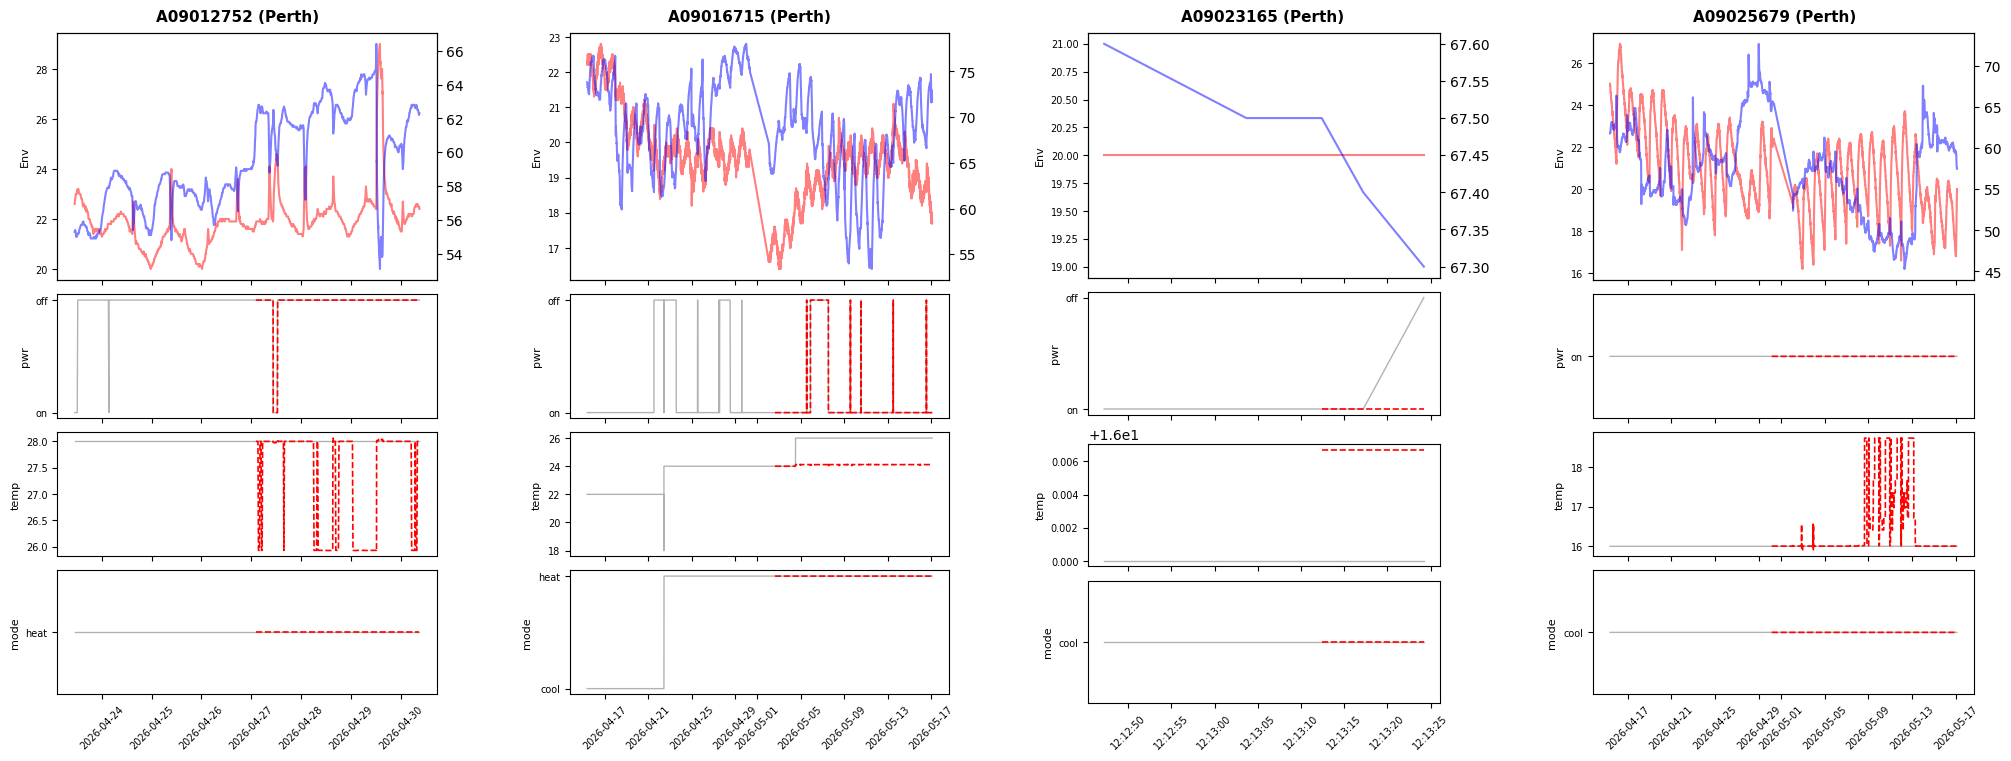

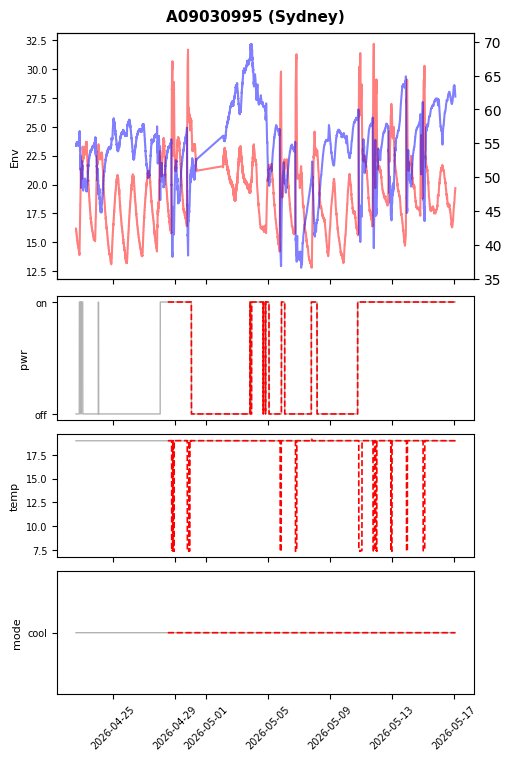

In [31]:
# Extract the unique IDs for XGBoost struggling devices
xgb_struggling_ids = struggling_devices['device.id'].unique().tolist()

print(f"Plotting {len(xgb_struggling_ids)} struggling devices for XGBoost...")

# Call the plot function using the XGBoost models dictionary
plot_device_decomposition_grid(
    df=df_processed, 
    model_dict=models,              # <--- Uses XGBoost models
    cities='All',                   # Checks all cities for these IDs
    device_ids=xgb_struggling_ids,  # Only plots these specific devices
    targets=['mqtt_state.pwr', 'mqtt_state.temp', 'mqtt_state.mode']
)

In [ ]:
# Plots every device in Perth for all target columns

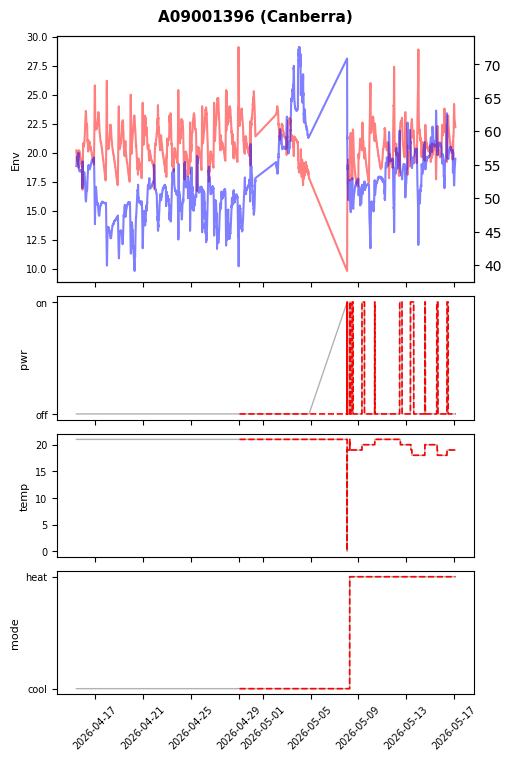

In [32]:
plot_device_decomposition_grid(
    df=df_processed, 
    model_dict=lr_models, 
    cities='Canberra', 
    targets=['mqtt_state.pwr', 'mqtt_state.temp', 'mqtt_state.mode']
)

In [33]:
import pandas as pd

def print_model_equations(model_dict, feature_names):
    for target, pipeline in model_dict.items():
        print(f"\n{'='*60}")
        print(f" TARGET: {target}")
        print(f"{'='*60}")
        
        # 1. Extract the specific model from the pipeline
        if target == 'mqtt_state.temp':
            model = pipeline.named_steps['regressor']
            model_type = "Linear Regression"
        else:
            model = pipeline.named_steps['classifier']
            model_type = "Logistic Regression"
            
        # 2. Get Intercept and Coefficients
        intercept = model.intercept_
        coeffs = model.coef_
        
        # 3. Handle Classification (Multi-class creates multiple equations)
        if model_type == "Logistic Regression":
            classes = model.classes_
            # Binary classification has 1 set of coeffs, Multi-class has one per class
            if len(classes) <= 2:
                print(f"Type: Binary {model_type}")
                print(f"Intercept (Bias): {intercept[0]:.4f}")
                df_coeffs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs[0]})
                print(df_coeffs.to_string(index=False))
            else:
                print(f"Type: Multi-class {model_type} ({len(classes)} classes)")
                for idx, class_name in enumerate(classes):
                    print(f"\n--- Class: {class_name} ---")
                    print(f"Intercept: {intercept[idx]:.4f}")
                    df_coeffs = pd.DataFrame({'Feature': feature_names, 'Weight': coeffs[idx]})
                    print(df_coeffs.to_string(index=False))
                    
        # 4. Handle Regression
        else:
            print(f"Type: {model_type}")
            print(f"Intercept: {intercept:.4f}")
            df_coeffs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coeffs})
            print(df_coeffs.to_string(index=False))

# Call the function
print_model_equations(lr_models, feature_cols)


 TARGET: mqtt_state.pwr
Type: Binary Logistic Regression
Intercept (Bias): -2.6749
               Feature  Coefficient
         mqtt_data.hum     0.141137
        mqtt_data.temp    -0.011210
    lag_mqtt_state.pwr     5.063728
   lag_mqtt_state.temp    -0.019644
   lag_mqtt_state.mode    -0.100187
    lag_mqtt_state.fan    -0.021239
lag_@mqtt_state.hlouve     0.004908
lag_@mqtt_state.vlouve    -0.007349

 TARGET: mqtt_state.temp
Type: Linear Regression
Intercept: 22.0318
               Feature  Coefficient
         mqtt_data.hum     0.001349
        mqtt_data.temp     0.000863
    lag_mqtt_state.pwr     0.000436
   lag_mqtt_state.temp     2.314346
   lag_mqtt_state.mode     0.000957
    lag_mqtt_state.fan    -0.001022
lag_@mqtt_state.hlouve     0.000247
lag_@mqtt_state.vlouve     0.000376

 TARGET: mqtt_state.mode
Type: Multi-class Logistic Regression (5 classes)

--- Class: auto ---
Intercept: -10.2691
               Feature     Weight
         mqtt_data.hum   0.233595
        mqtt_d

In [34]:
def print_xgboost_importance(model_dict, feature_names):
    for target, (model, le) in model_dict.items():
        print(f"\n{'='*60}")
        print(f" TARGET: {target}")
        print(f"{'='*60}")
        
        # Get the importance scores (Gain is usually the most meaningful)
        # 'gain' = the average improvement in accuracy brought by a feature to the branches it is on
        importance = model.get_booster().get_score(importance_type='gain')
        
        # Map the 'f0', 'f1' names back to your actual column names
        # XGBoost often renames columns internally to f0, f1...
        # We match them based on order in feature_cols
        mapped_importance = {}
        for i, col in enumerate(feature_names):
            key = f'f{i}'
            if key in importance:
                mapped_importance[col] = importance[key]
            elif col in importance: # Sometimes it keeps the original name
                mapped_importance[col] = importance[col]

        # Convert to DataFrame for easy viewing
        df_imp = pd.DataFrame({
            'Feature': mapped_importance.keys(),
            'Importance (Gain)': mapped_importance.values()
        }).sort_values(by='Importance (Gain)', ascending=False)

        print(df_imp.to_string(index=False))
        
        # Optional: Quick plot
        # df_imp.set_index('Feature').plot(kind='barh', title=f"Importance: {target}")

# Call the function
print_xgboost_importance(models, feature_cols)


 TARGET: mqtt_state.pwr
               Feature  Importance (Gain)
    lag_mqtt_state.pwr       20518.056641
   lag_mqtt_state.mode           6.738150
lag_@mqtt_state.vlouve           4.394961
    lag_mqtt_state.fan           4.238016
   lag_mqtt_state.temp           3.785677
lag_@mqtt_state.hlouve           3.396888
         mqtt_data.hum           3.035658
        mqtt_data.temp           3.004774

 TARGET: mqtt_state.temp
               Feature  Importance (Gain)
   lag_mqtt_state.temp        8597.319336
   lag_mqtt_state.mode          10.758098
        mqtt_data.temp           9.848997
         mqtt_data.hum           9.365477
    lag_mqtt_state.fan           7.950294
lag_@mqtt_state.hlouve           4.322811
lag_@mqtt_state.vlouve           3.614144
    lag_mqtt_state.pwr           1.531465

 TARGET: mqtt_state.mode
               Feature  Importance (Gain)
   lag_mqtt_state.mode        4053.817139
   lag_mqtt_state.temp           1.264166
lag_@mqtt_state.hlouve           1.166616